In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

import utils_data
import utils_plot

inf >> read data shape is torch.Size([17420, 1])


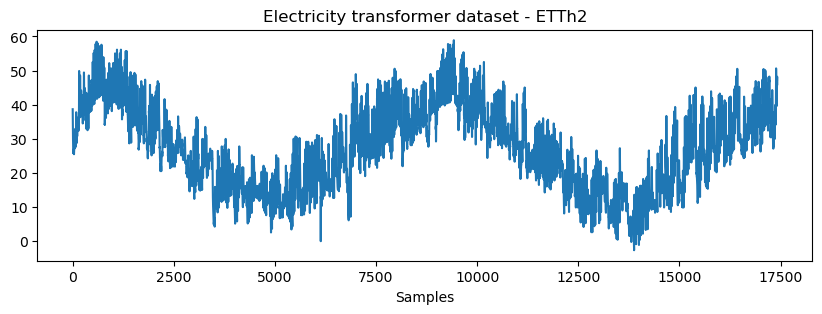

In [2]:
# --! data readout from a file --!

def convert(s):
    """Converts a string ``s`` to a float."""
    return float(s)

def read_detuning(name: str, jcol_read: list[int], nrow_skip: int=0, delim: str=None):
    return torch.tensor(
        np.loadtxt(
            name,
            delimiter=delim,
            skiprows=nrow_skip,
            usecols=jcol_read,
            dtype=np.float32,
            ndmin=2,
            converters=convert))

dataname = '../../data/baselines/ETTh2.csv'
rawdata  = read_detuning(dataname, jcol_read=[7], nrow_skip=1, delim=',')

print(f'inf >> read data shape is {rawdata.shape}')

plt.figure(figsize=(10, 3))
plt.title('Electricity transformer dataset - ETTh2')
plt.plot(rawdata[:, 0])
plt.xlabel('Samples')
plt.show()

inf >> number of training and test samples is 8545 and 8875, respectively


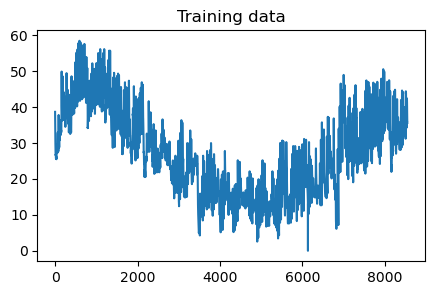

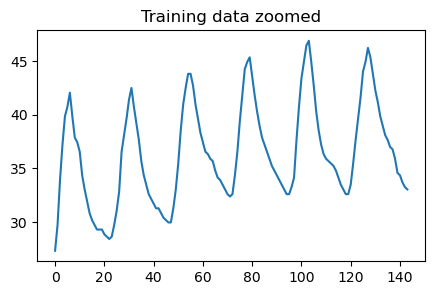

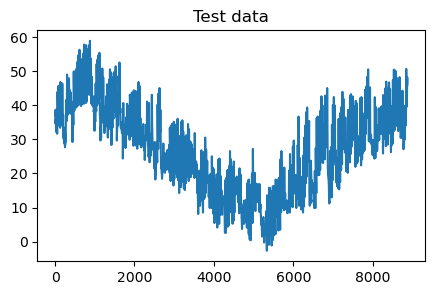

In [3]:
train_io, test_io = train_test_split(rawdata, shuffle=False, train_size=8545)

train_nsample = train_io.shape[0]
test_nsample  = test_io.shape[0]

print(f'inf >> number of training and test samples is {train_nsample} and {test_nsample}, respectively')

plt.figure(figsize=(0.5 * 10, 3))
plt.title('Training data')
plt.plot(train_io)
plt.show()

plt.figure(figsize=(0.5 * 10, 3))
plt.title('Training data zoomed')
plt.plot(train_io[2000:2144])
plt.show()

plt.figure(figsize=(0.5 * 10, 3))
plt.title('Test data')
plt.plot(test_io)
plt.show()

In [4]:
# --! load a trained stationary model --!

model = torch.load('../../models/baselines/et_kind_filter.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=576, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=6, out_features=6, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=108, bias=True)
          (1): Identity()
        )
      )
    )
    (pre_me

In [5]:
datasaved = True

if datasaved:
    datum            = train_io
    savedir          = '../../data/baselines/et_train_stat'
    utils_data.save_stat(model, savedir, [datum], size_factor=100)

In [6]:
datasaved = True

if datasaved:
    datum            = train_io
    savedir          = '../../data/baselines/et_train_trans'
    utils_data.save_trans(model, savedir, [datum])

In [7]:
datasaved = True

if datasaved:
    timeseries_nsample = model.lookback_nsample + model.forecast_nsample

    savedir_stat  = '../../data/baselines/et_train_stat'
    savedir_trans = '../../data/baselines/et_train_trans'
    savedir_mixed = '../../data/baselines/et_train_mixed'

    utils_data.save_mixed_dataset(savedir_stat, savedir_trans, timeseries_nsample, savedir_mixed)

In [8]:
datasaved = True

if datasaved:
    savedir  = '../../data/baselines/et_test'
    filename = 'eval'
    testdata = test_io
    print(testdata.shape)
    testdata = torch.unsqueeze(testdata, 0)
    utils_data.write_datafile(f'{savedir}/{filename}', testdata)

torch.Size([8875, 1])
